In [43]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, LineString, Polygon
import fiona
import matplotlib.pyplot as plt
from pathlib import Path
from shapely import wkt #for dealing with polys encoded with this vector geom format
plt.style.use('bmh') #for plotting geometries

In [9]:
path = '/Users/jenniferbadger/Documents/ArcGIS Pro 3.5/Chapter1/Kern_Co_Richgrove_Template/i03_WaterDistricts.csv'

df = pd.read_csv(path)

df.head()

,OBJECTID,AGENCYNAME,SOURCE,AGENCYUNIQUEID,LASTMODIFIEDDATE,MODIFIEDBY,SOURCECOMMENTS,Date_Data_Applies_To,GlobalID,created_user,created_date,last_edited_user,last_edited_date,Polygon_ID,ShapeSTArea,ShapeSTLength
0,1,Del Puerto Water District,SCRO,706,2013/11/07 00:00:00+00,source,NaN,2013/11/07 00:00:00+00,{00DBDCAE-33DA-4263-AB0C-C2E0AF348F6E},ATLAS_WMAS,2025/12/08 16:24:05+00,ATLAS_WMAS,2025/12/08 16:24:05+00,{E53FAE01-633C-44AA-9958-3956EDF8E43D},3.526610e+08,371605.715647
1,2,West Stanislaus Irrigation District,SCRO,2688,2013/11/07 00:00:00+00,source,NaN,2013/11/07 00:00:00+00,{E1A4404C-7AFB-49B3-BEBB-A551FDA8A098},ATLAS_WMAS,2025/12/08 16:24:05+00,ATLAS_WMAS,2025/12/08 16:24:05+00,{1FE35070-C4AE-494F-8931-A9923C0E6909},1.398318e+08,102931.290433
2,3,El Solyo Water District,SCRO,828,2013/11/07 00:00:00+00,source,NaN,2013/11/07 00:00:00+00,{C5CD3CC5-B94B-497D-8A90-06E9A89AFB55},ATLAS_WMAS,2025/12/08 16:24:05+00,ATLAS_WMAS,2025/12/08 16:24:05+00,{6480F269-E2FA-450F-8049-77430506A12F},2.609992e+07,21869.312562
3,4,Rock Creek Water District,SCRO,2098,2013/11/07 00:00:00+00,source,NaN,2013/11/07 00:00:00+00,{12CDA8EF-A2E8-4BA0-AD16-348659D77521},ATLAS_WMAS,2025/12/08 16:24:05+00,ATLAS_WMAS,2025/12/08 16:24:05+00,{2DA97EC0-A4DF-434D-A2CF-B8B538B42107},1.202210e+07,22108.064302
4,5,Turlock Irrigation District,SCRO,2525,2013/11/07 00:00:00+00,source,NaN,2013/11/07 00:00:00+00,{125C2D0D-5249-4A70-BA60-6D0818B30A61},ATLAS_WMAS,2025/12/08 16:24:05+00,ATLAS_WMAS,2025/12/08 16:24:05+00,{7A193304-52E6-41D2-AB91-C05EE8CA1DB8},1.206934e+09,283230.277126


In [10]:
url = "https://hub.arcgis.com/api/v3/datasets/538bfc2e4ad64ff78ff18fbb8ca36033_0/downloads/data?format=csv&spatialRefId=3857&where=1%3D1"

api_df = pd.read_csv(url)

print(df.head())

   OBJECTID                           AGENCYNAME SOURCE  AGENCYUNIQUEID  \
0         1            Del Puerto Water District   SCRO             706   
1         2  West Stanislaus Irrigation District   SCRO            2688   
2         3              El Solyo Water District   SCRO             828   
3         4            Rock Creek Water District   SCRO            2098   
4         5          Turlock Irrigation District   SCRO            2525   

         LASTMODIFIEDDATE MODIFIEDBY SOURCECOMMENTS    Date_Data_Applies_To  \
0  2013/11/07 00:00:00+00     source            NaN  2013/11/07 00:00:00+00   
1  2013/11/07 00:00:00+00     source            NaN  2013/11/07 00:00:00+00   
2  2013/11/07 00:00:00+00     source            NaN  2013/11/07 00:00:00+00   
3  2013/11/07 00:00:00+00     source            NaN  2013/11/07 00:00:00+00   
4  2013/11/07 00:00:00+00     source            NaN  2013/11/07 00:00:00+00   

                                 GlobalID created_user  \
0  {00DBDCAE-33D

In [11]:
api_df.columns

Index(['OBJECTID', 'AGENCYNAME', 'SOURCE', 'AGENCYUNIQUEID',
       'LASTMODIFIEDDATE', 'MODIFIEDBY', 'SOURCECOMMENTS',
       'Date_Data_Applies_To', 'GlobalID', 'created_user', 'created_date',
       'last_edited_user', 'last_edited_date', 'Polygon_ID', 'ShapeSTArea',
       'ShapeSTLength'],
      dtype='object')

In [45]:
#There is no geometry in that obj so adding this
import requests
url = "https://utility.arcgis.com/usrsvcs/servers/538bfc2e4ad64ff78ff18fbb8ca36033/rest/services/Boundaries/i03_WaterDistricts/MapServer/0/query"

params = {
    #SQl filter, i.e. return all the layer features (incl. geometry)
    "where": "1=1",
    #* returns all attributes
    "outFields": "*",
    "returnGeometry": "true",
    "outSR": 4326,
    "f": "geojson"
}

r = requests.get(url, params=params)

print(r)

<Response [200]>


In [56]:
api_gdf = gpd.read_file(r.text)

print(api_gdf.head())

   OBJECTID                           AGENCYNAME SOURCE  AGENCYUNIQUEID  \
0         1            Del Puerto Water District   SCRO             706   
1         2  West Stanislaus Irrigation District   SCRO            2688   
2         3              El Solyo Water District   SCRO             828   
3         4            Rock Creek Water District   SCRO            2098   
4         5          Turlock Irrigation District   SCRO            2525   

   LASTMODIFIEDDATE MODIFIEDBY SOURCECOMMENTS  Date_Data_Applies_To  \
0      1.383782e+12     source           None          1.383782e+12   
1      1.383782e+12     source           None          1.383782e+12   
2      1.383782e+12     source           None          1.383782e+12   
3      1.383782e+12     source           None          1.383782e+12   
4      1.383782e+12     source           None          1.383782e+12   

                                 GlobalID  Shape.STArea()  Shape.STLength()  \
0  {00DBDCAE-33DA-4263-AB0C-C2E0AF348F6E}  

In [57]:
api_gdf.geometry.head()


0    MULTIPOLYGON (((-121.0857 37.34067, -121.08559...
1    MULTIPOLYGON (((-121.29715 37.66738, -121.2972...
2    POLYGON ((-121.23216 37.59463, -121.23196 37.5...
3    POLYGON ((-120.83439 37.97385, -120.84355 37.9...
4    MULTIPOLYGON (((-120.67371 37.64477, -120.6755...
Name: geometry, dtype: geometry

In [58]:
api_gdf.geom_type.value_counts()

Polygon         1645
MultiPolygon     355
Name: count, dtype: int64

<Axes: >

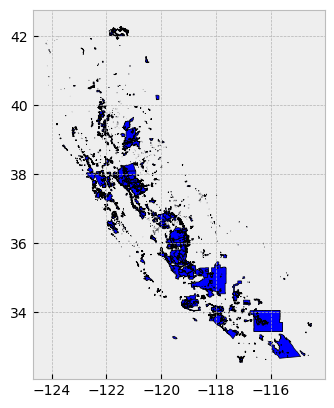

In [59]:
api_gdf.plot(
    edgecolor = 'black',
    facecolor = 'blue')
    

In [60]:
api_gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [61]:
api_gdf = api_gdf.drop(columns = [
     'MODIFIEDBY', 
    'created_user', 
    'last_edited_user',
    "SOURCECOMMENTS"])

In [69]:
api_gdf = api_gdf.rename(columns={
    "Date_Data_Applies_To": "DateApply",
    "AGENCYUNIQUEID": "AgencyUID",
    "LASTMODIFIEDDATE": "LastMod",
    'last_edited_date': 'date',
    'Shape.STArea()' : 'ShapeArea',
    'Shape.STLength()':'ShapeLen',
     'created_date' : 'init_date' })

In [70]:
api_gdf.columns


Index(['OBJECTID', 'AGENCYNAME', 'SOURCE', 'AgencyUID', 'LastMod', 'DateApply',
       'GlobalID', 'ShapeArea', 'ShapeLen', 'init_date', 'date', 'Polygon_ID',
       'geometry'],
      dtype='object')

In [71]:
out_dir = Path(r"/Users/jenniferbadger/Documents/ArcGIS Pro 3.5/Chapter1/water_districts")
out_dir.mkdir(parents=True, exist_ok=True)

out_shp = out_dir / "water_districts.shp"

api_gdf.to_file(out_shp, driver="ESRI Shapefile")